In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
df=pd.read_csv('price_sample.csv')

In [25]:
df.head()

,para1,para2,para3,para4,price
0,1,662.0,3000.0,3.8,73.49
1,1,340.0,2760.0,9.2,300.00
2,0,16.0,2700.0,3.0,130.00
3,1,17.0,12320.0,6.4,365.00
4,1,610.0,2117.0,10.8,357.50


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   para1   10003 non-null  int64  
 1   para2   9997 non-null   float64
 2   para3   10003 non-null  float64
 3   para4   9998 non-null   float64
 4   price   10003 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 390.9 KB


In [27]:
df.shape

(10003, 5)

In [28]:
df.columns

Index(['para1', 'para2', 'para3', 'para4', 'price'], dtype='object')

In [29]:
df.describe()

,para1,para2,para3,para4,price
count,10003.000000,9997.000000,10003.000000,9998.000000,10003.000000
mean,1.380986,447.270681,9547.975527,8.458024,433.774924
std,3.500408,220.913801,8022.286943,4.613645,277.443154
min,0.000000,16.000000,200.000000,1.000000,50.730000
25%,1.000000,301.000000,2899.500000,4.000000,250.000000
50%,1.000000,434.000000,6446.000000,7.200000,370.000000
75%,1.000000,582.000000,15000.000000,13.600000,550.000000
max,337.000000,2554.000000,34782.000000,27.200000,5700.000000


In [30]:
df.isnull().sum()

para1    0
para2    6
para3    0
para4    5
price    0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(215)

In [32]:
df.drop_duplicates()

,para1,para2,para3,para4,price
0,1,662.0,3000.0,3.8,73.49
1,1,340.0,2760.0,9.2,300.00
2,0,16.0,2700.0,3.0,130.00
3,1,17.0,12320.0,6.4,365.00
4,1,610.0,2117.0,10.8,357.50
...,...,...,...,...,...
9998,3,386.0,5000.0,12.0,460.00
9999,1,386.0,3250.0,8.0,325.00
10000,0,190.0,8856.0,5.6,133.33
10001,3,717.0,5000.0,13.6,820.00


In [33]:
df['para2'] = df['para2'].fillna(df['para2'].mean())
df['para4'] = df['para4'].fillna(df['para4'].mean())

In [34]:
df.isnull().sum()

para1    0
para2    0
para3    0
para4    0
price    0
dtype: int64

In [35]:
X = df.drop("price", axis=1)
y = df["price"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [45]:
model=LinearRegression()

In [46]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
y_pred=model.predict(X_test)

In [51]:
mse=mean_squared_error(y_test,y_pred)

In [52]:
r2=r2_score(y_test,y_pred)

In [54]:
print(f"Mean Squarred Error:{mse}")
print(f"R^2 Score:{r2}")

Mean Squarred Error:39723.1462352541
R^2 Score:0.5450289027570887


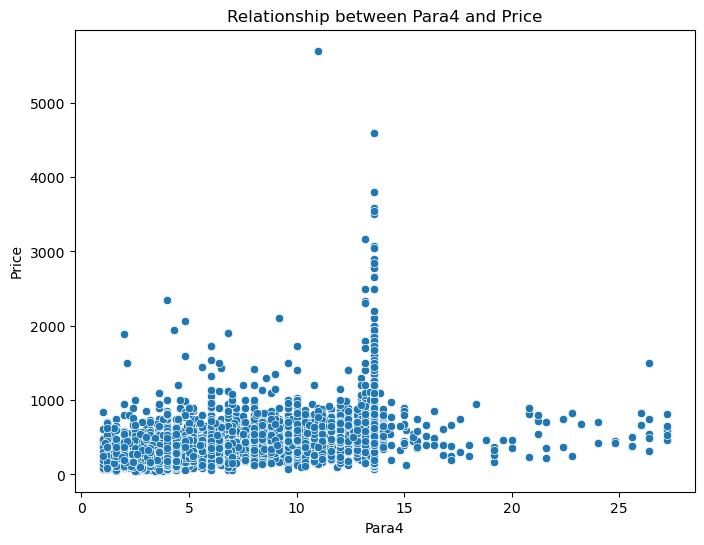

In [60]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="para4", y="price")
plt.title("Relationship between Para4 and Price")
plt.xlabel("Para4")
plt.ylabel("Price")
plt.show()

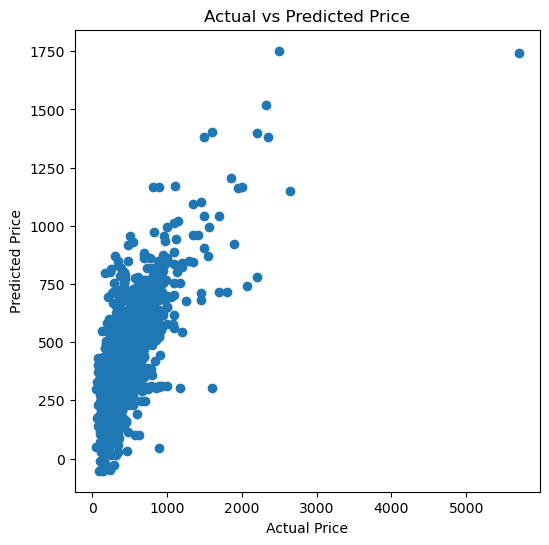

In [61]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

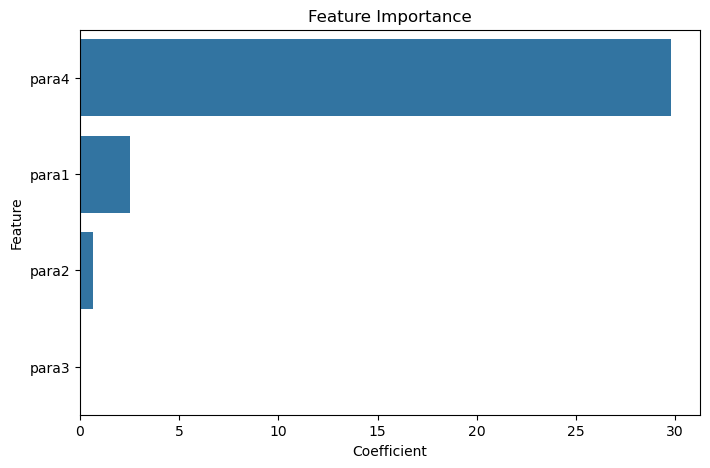

In [62]:
importance = pd.DataFrame({ "Feature": X.columns, "Coefficient": model.coef_})
importance = importance.sort_values(by="Coefficient", ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=importance, x="Coefficient", y="Feature")
plt.title("Feature Importance")
plt.show()

In [ ]:
Была построена модель линейной регрессии для прогнозирования цены. Перед обучением были обработаны пропущенные значения и проверены дубликаты. 
Данные были разделены на обучающую и тестовую выборки. Результаты модели: MSE = 39723.15, R² = 0.545. 
Это означает, что модель объясняет около 54,5% изменения цены и имеет среднюю точность.
По графику Relationship between Para4 and Price видно, что признак para4 оказывает заметное влияние на цену.
Диаграмма Feature Importance также показывает, что para4 является самым значимым признаком при прогнозировании цены.